In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
df=pd.read_csv("wine_quality.csv")
print(df.head(3))

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    12.87        4.61  2.48               21.5       86.0           1.70   
1    13.28        1.64  2.84               15.5      110.0           2.60   
2    12.82        3.37  2.30               19.5       88.0           1.48   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        0.65                  0.47             0.86             7.65  0.54   
1        2.68                  0.34             1.36             4.60  1.09   
2        0.66                  0.40             0.97            10.26  0.72   

   od280/od315_of_diluted_wines  proline quality_label  
0                          1.86      NaN           low  
1                          2.78    880.0          high  
2                          1.75    685.0           low  


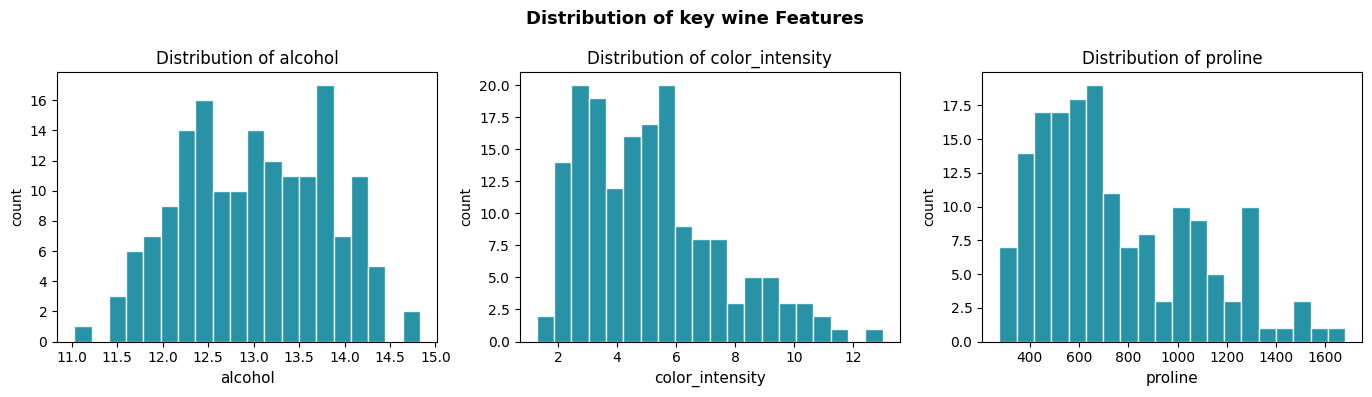

In [ ]:
#bins alpla --> histogram
fig, axes= plt.subplots(1,3, figsize= (14,4))
fig.suptitle("Distribution of key wine Features", fontsize=13, fontweight="bold")

for ax, col in zip(axes, ["alcohol", "color_intensity", "proline"]):
    ax.hist(df[col], bins=20, color= "#028098", edgecolor="white", alpha=0.85)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("count")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

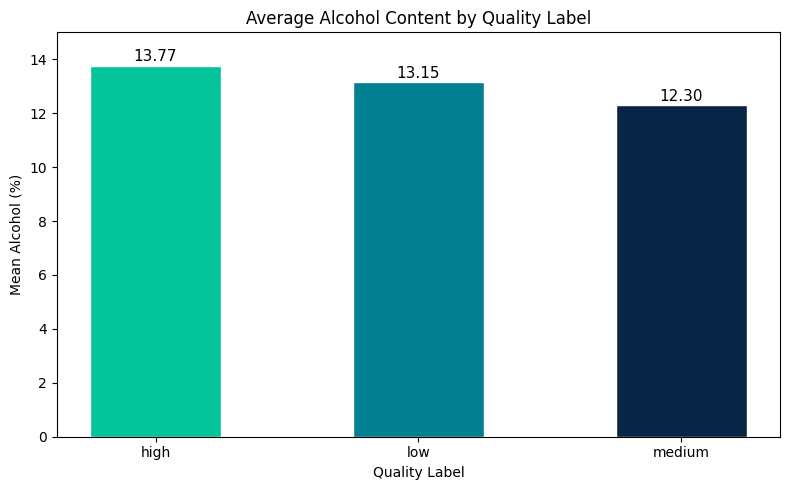

In [ ]:
import matplotlib.pyplot as plt

avg_alcohol = (
    df.groupby("quality_label")["alcohol"].mean().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    avg_alcohol.index,
    avg_alcohol.values,
    color=["#02C39A", "#028090", "#082545"],
    edgecolor="white",
    width=0.5
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title("Average Alcohol Content by Quality Label", fontsize=12)
ax.set_xlabel("Quality Label")
ax.set_ylabel("Mean Alcohol (%)")
ax.set_ylim(0, 15)

plt.tight_layout()
plt.show()

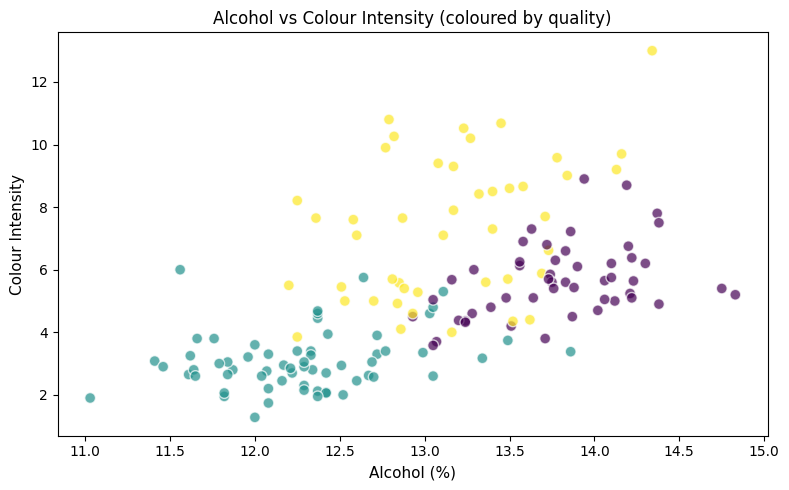

In [ ]:
colour_map = {"high": 0, "medium": 1, "low": 2}
colours = df["quality_label"].map(colour_map)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["alcohol"], df["color_intensity"], c=colours, cmap="viridis", alpha=0.7, edgecolors="white", s=60)

ax.set_xlabel("Alcohol (%)", fontsize=11)
ax.set_ylabel("Colour Intensity", fontsize=11)
ax.set_title("Alcohol vs Colour Intensity (coloured by quality)", fontsize=12)

plt.tight_layout()

plt.show()

<ipython-input-6-0a28cc879656>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="quality_label", y="alcohol", order=order, palette="Set2", ax=axes[0])
<ipython-input-6-0a28cc879656>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="quality_label", y="proline", order=order, palette="Set2", ax=axes[1])


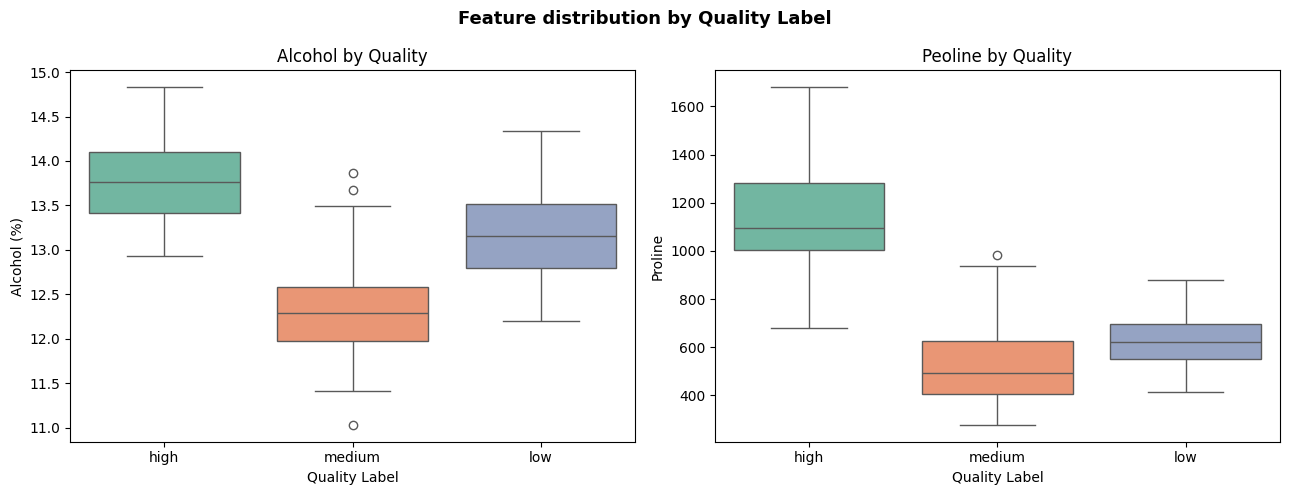

In [ ]:
fig, axes= plt.subplots(1,2,figsize=(13,5))
fig.suptitle("Feature distribution by Quality Label", fontsize=13, fontweight="bold")
order=["high", "medium", "low"]
sns.boxplot(data=df, x="quality_label", y="alcohol", order=order, palette="Set2", ax=axes[0])
axes[0].set_title("Alcohol by Quality")
axes[0].set_xlabel("Quality Label")
axes[0].set_ylabel("Alcohol (%)")

sns.boxplot(data=df, x="quality_label", y="proline", order=order, palette="Set2", ax=axes[1])
axes[1].set_title("Peoline by Quality")
axes[1].set_xlabel("Quality Label")
axes[1].set_ylabel("Proline")

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

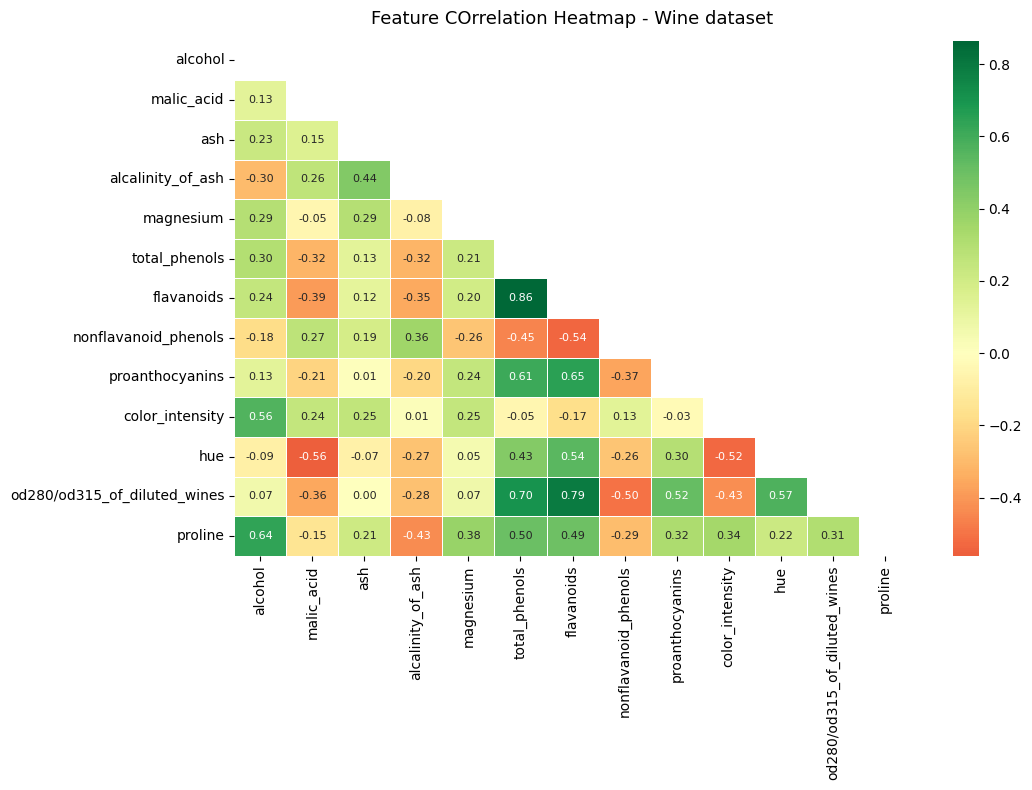

In [ ]:
import numpy as np
#corr is a function uses pearson correlation for the numerical data
numeric_df=df.drop(columns=["quality_label"])
corr=numeric_df.corr()
mask=np.triu(np.ones_like(corr, dtype=bool))
fig, ax=plt.subplots(figsize=(11,8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=0.4, annot_kws={"size":8}, ax=ax)
ax.set_title("Feature COrrelation Heatmap - Wine dataset", fontsize=13, pad=12)
plt.tight_layout()
plt.show

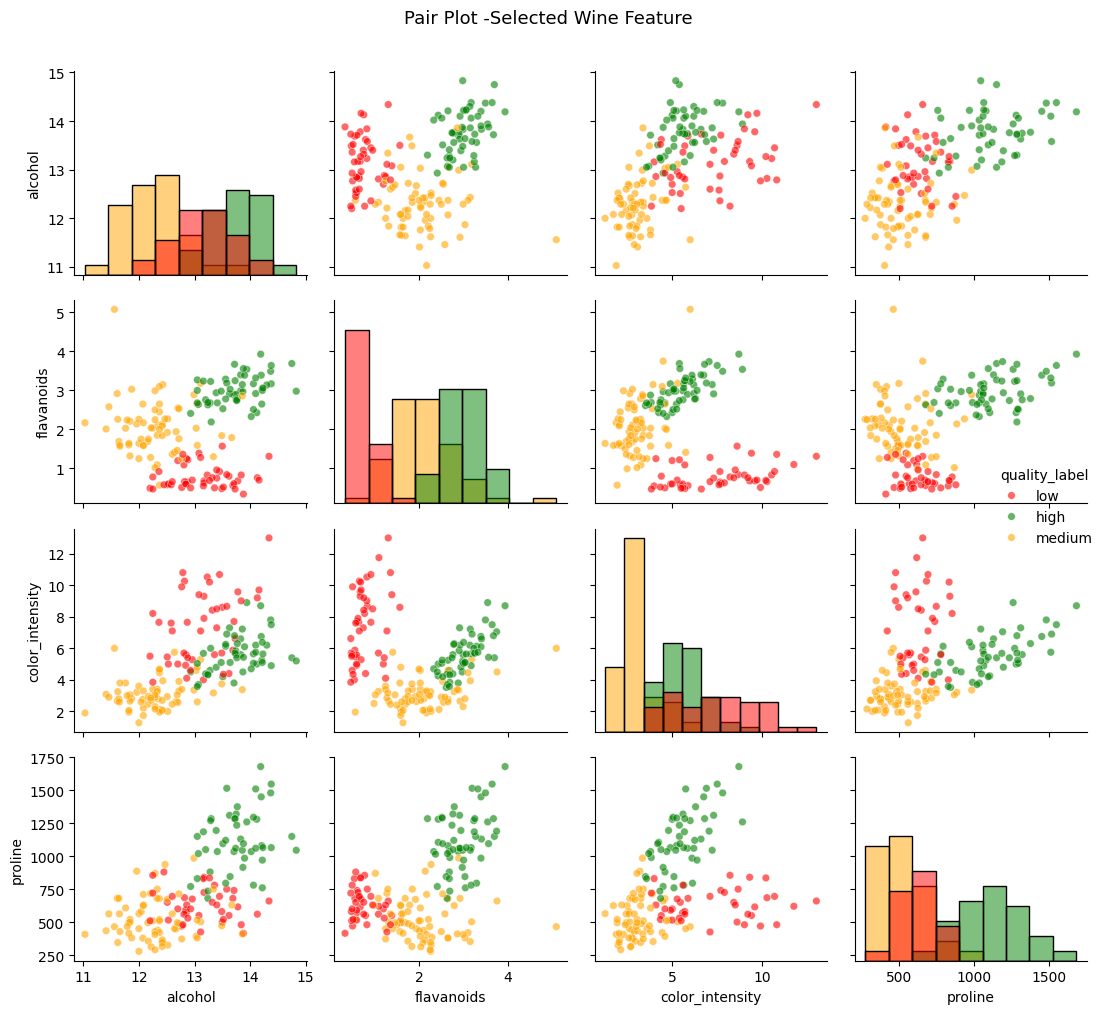

In [ ]:
subset_df=df[["alcohol", "flavanoids", "color_intensity", "proline", "quality_label"]]
#quality_label is not include in the pairplot because it is target variable
pair_plot=sns.pairplot(subset_df, hue="quality_label", palette={"high": "green", "medium": "orange", "low": "red"}, diag_kind="hist", plot_kws={"alpha":0.6, "s": 30})
pair_plot.figure.suptitle("Pair Plot -Selected Wine Feature", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
le=LabelEncoder()
df["quality_le"]=le.fit_transform(df["quality_label"])
print("label Encoder mapping", dict(zip(le.classes_, le.transform(le.classes_))))

label Encoder mapping {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}


In [ ]:
order_map={"low": 0, "medium":1, "high":2}
df["quality_label"]=df["quality_label"].map(order_map)
print("Manual ordinal mapping:" , order_map)

Manual ordinal mapping: {'low': 0, 'medium': 1, 'high': 2}


In [ ]:
df_ohe=pd.get_dummies(df, columns=["quality_label"], drop_first=True)
new_cols=[c for c in df_ohe.columns if "quality_label" in c]
print("OOHE new columns : {df.shape}. |  after : {df.shape}")

OOHE new columns : {df.shape}. |  after : {df.shape}


In [ ]:
df_eng=df.copy()

df_eng["alcohol_acidity_ratio"]= df_eng["alcohol"]/ df_eng["malic_acid"]+1e-6
df_eng["flavonoids_phenols_ratio"]= df_eng["flavanoids"]/ df_eng["total_phenols"]+1e-6
df_eng["color_per_alcohol"]= df_eng["color_intensity"]/ df_eng["alcohol"]+1e-6

In [ ]:
# Bin alcohol into categories
df_eng["alcohol_bins"] = pd.cut(df_eng["alcohol"], 3, labels = ["low", "medium", "high"])

# Showing distribution
print(df_eng["alcohol_bins"].value_counts())

alcohol_bins
medium    81
high      48
low       37
Name: count, dtype: int64


In [ ]:
# Compare alcohol vs quality
pd.crosstab(df_eng["alcohol_bins"], df_eng["quality_label"])


corr= df_eng.corr(numeric_only=True).abs()
high_corr=corr.index[(corr>0.85).sum()>1].tolist()
print("Highly correlated features to check: ")
print(high_corr)

Highly correlated features to check: 
['malic_acid', 'total_phenols', 'flavanoids', 'color_intensity', 'alcohol_acidity_ratio', 'flavonoids_phenols_ratio', 'color_per_alcohol']


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X= df_eng.select_dtypes(include=[np.number]).dropna()

scaler=StandardScaler()
X_scaled= scaler.fit_transform(X)

pca=PCA(n_components=4)
X_pca=pca.fit_transform(X_scaled)

In [ ]:
print("Explained variance ratio: ", np.round(pca.explained_variance_ratio_, 2))
print("Totalvariance explained: ", round(sum(pca.explained_variance_ratio_)*100,1), "%")
print("Before PCA: ", X_scaled.shape)
print("After: ", X_pca.shape)

Explained variance ratio:  [0.35 0.23 0.1  0.07]
Totalvariance explained:  74.6 %
Before PCA:  (133, 18)
After:  (133, 4)
